# SKR vs Distance: Finite BB84 vs `bb84_server_client`

This notebook compares the final secret key rate (SKR) versus fiber distance for two BB84 implementations:

- **Finite BB84** from `bb84_finite.py`.
- **Server-client BB84** from `ServerClientBB84/bb84_server_client.py`, using the final key after error correction and privacy amplification.

To keep the comparison simple, both cases use the same shared physical parameters where possible. The server-client simulation is wired directly from channel to detector so it stays close to the finite BB84 model and does not include Eve.

In [1]:
import asyncio
import contextlib
import io
import os
import sys

import nest_asyncio
import matplotlib.pyplot as plt
import numpy as np

nest_asyncio.apply()


from bb84_finite import Source, Channel, Detector as FiniteDetector, Protocol

# Ensure we can import from the ServerClientBB84 directory
current_dir = os.getcwd()
target_dir = os.path.join(current_dir, 'ServerClientBB84')
if target_dir not in sys.path:
    sys.path.append(target_dir)

try:
    from bb84_server_client import AliceServer, BobClient, QuantumChannel, Detector, Eve, APIClient
except ImportError:
    sys.path.append(os.getcwd())
    from bb84_server_client import AliceServer, BobClient, QuantumChannel, Detector, Eve, APIClient

def run_async(coro):
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
    return loop.run_until_complete(coro)

print('Imports ready.')

[NR-LDPC] GPU Detected: 1 device(s). Acceleration ENABLED.
[NR-LDPC] Sionna Library Loaded Successfully.
Imports ready.


In [2]:
# Shared parameters
distance_km = np.linspace(0, 200, 20)
source_freq_hz = 1e7
block_size = int(1e6)
mean_photon_num = 1.0
alignment_error = 0.005
fiber_loss_db_km = 0.2
detector_efficiency = 0.8
dark_count_rate = 1e4
time_window = 1e-9
optical_error_rate = 0.01
dark_count_prob = 1 - np.exp(-dark_count_rate * time_window)

print('Common parameters:')
print(f'  Distances (km): {distance_km.tolist()}')
print(f'  Source frequency (Hz): {source_freq_hz:.2e}')
print(f'  Block size / emitted qubits: {block_size}')
print(f'  Fiber loss (dB/km): {fiber_loss_db_km}')
print(f'  Detector efficiency: {detector_efficiency}')
print(f'  Dark count probability: {dark_count_prob:.3e}')
print(f'  Optical error rate: {optical_error_rate}')

Common parameters:
  Distances (km): [0.0, 10.526315789473685, 21.05263157894737, 31.578947368421055, 42.10526315789474, 52.631578947368425, 63.15789473684211, 73.6842105263158, 84.21052631578948, 94.73684210526316, 105.26315789473685, 115.78947368421053, 126.31578947368422, 136.84210526315792, 147.3684210526316, 157.89473684210526, 168.42105263157896, 178.94736842105266, 189.47368421052633, 200.0]
  Source frequency (Hz): 1.00e+07
  Block size / emitted qubits: 1000000
  Fiber loss (dB/km): 0.2
  Detector efficiency: 0.8
  Dark count probability: 1.000e-05
  Optical error rate: 0.01


In [3]:
# Finite BB84 SKR vs distance
finite_source = Source(
    freq=source_freq_hz,
    mean_photon_num=mean_photon_num,
    q=1.0,
    alignment_error=alignment_error,
)
finite_channel = Channel(
    length_km=0.0,
    att_db_km=fiber_loss_db_km,
    channel_mode='fiber',
)
finite_detector = FiniteDetector(
    efficiency=detector_efficiency,
    dark_count_rate=dark_count_rate,
    time_window=time_window,
)
finite_protocol = Protocol(
    finite_source,
    finite_channel,
    finite_detector,
    epsilon_sec=1e-9,
    epsilon_cor=1e-9,
    f_ec=1.3,
)

finite_skr = finite_protocol.skr_vs_distance(distance_km, block_size)
print('Finite BB84 SKR computed.')

Finite BB84 SKR computed.


In [4]:
# Server-client BB84 final SKR vs distance
# The server-client stack here uses Polar reconciliation + Toeplitz privacy amplification.
async def server_client_skr_at_distance(length_km):
    seed = 44444
    channel = QuantumChannel('Fiber', length_km, fiber_loss_db_km, optical_error_rate, next_actor=None, seed=seed)
    alice = AliceServer('Alice', channel, num_qubits=block_size, verbose=False, seed=seed + 1)
    api = APIClient(alice)
    # Use cascade for smoother curves, handle errors gracefully
    bob = BobClient('Bob', api, protocol='cascade', pa_protocol='toeplitz', seed=int(np.random.randint(0, 100000)), verbose=False)
    detector = Detector('Detector', detector_efficiency, dark_count_prob, parent_bob=bob, seed=seed + 3)
    channel.next_actor = detector

    actors = [alice, channel, detector, bob]
    tasks = [asyncio.create_task(actor.start()) for actor in actors]
    results = {}

    try:
        with contextlib.redirect_stdout(io.StringIO()):
            await alice.run_quantum_transmission()
            await asyncio.sleep(0.5)
            results = await bob.run_classical_post_processing(block_size)
    except Exception as e:
        print(f"Error at {length_km}km: {e}")
        results = {}
    finally:
        for actor in actors:
            await actor.send(actor, ('STOP',))
        await asyncio.gather(*tasks)

    pa_length = results.get('pa_length', 0)
    if pa_length > 0:
        skr = (pa_length / block_size) * source_freq_hz
    else:
        skr = 0.0

    return skr, results

server_skr = []
server_results = []

for length_km in distance_km:
    skr, results = run_async(server_client_skr_at_distance(length_km))
    server_skr.append(skr)
    server_results.append(results)
    print(f'Distance {length_km:>5.1f} km -> final SKR = {skr:.3e} bits/s')

Distance   0.0 km -> final SKR = 2.630e+05 bits/s
Distance  10.5 km -> final SKR = 1.530e+05 bits/s
Distance  21.1 km -> final SKR = 9.378e+04 bits/s
Distance  31.6 km -> final SKR = 5.111e+04 bits/s
Distance  42.1 km -> final SKR = 3.627e+04 bits/s
Distance  52.6 km -> final SKR = 2.600e+04 bits/s
Distance  63.2 km -> final SKR = 9.350e+03 bits/s
Distance  73.7 km -> final SKR = 6.420e+03 bits/s
Distance  84.2 km -> final SKR = 6.380e+03 bits/s
Distance  94.7 km -> final SKR = 3.410e+03 bits/s
Distance 105.3 km -> final SKR = 1.290e+03 bits/s
Distance 115.8 km -> final SKR = 1.440e+03 bits/s
Distance 126.3 km -> final SKR = 8.300e+02 bits/s
Distance 136.8 km -> final SKR = 7.400e+02 bits/s
Distance 147.4 km -> final SKR = 0.000e+00 bits/s
Distance 157.9 km -> final SKR = 0.000e+00 bits/s
Distance 168.4 km -> final SKR = 0.000e+00 bits/s
Distance 178.9 km -> final SKR = 0.000e+00 bits/s
Distance 189.5 km -> final SKR = 0.000e+00 bits/s
Distance 200.0 km -> final SKR = 0.000e+00 bits/s


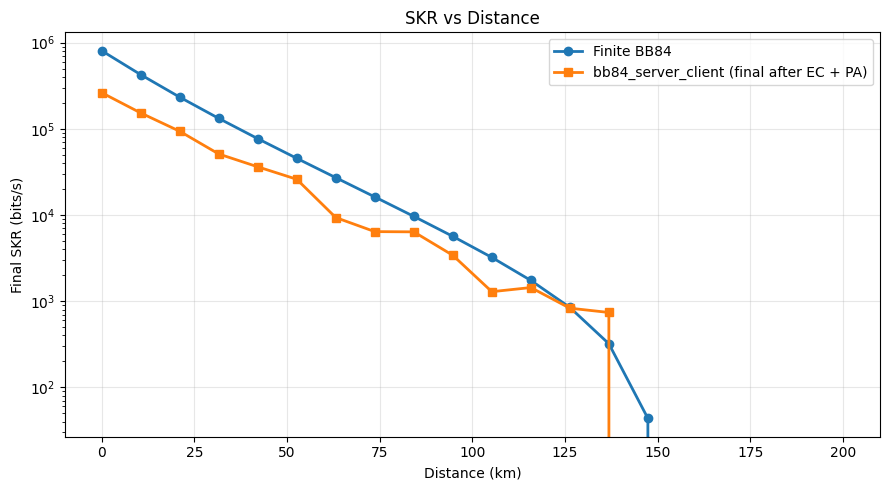

In [5]:
# Final comparison plot
plt.figure(figsize=(9, 5))
plt.semilogy(distance_km, finite_skr, 'o-', linewidth=2, label='Finite BB84')
plt.semilogy(distance_km, server_skr, 's-', linewidth=2, label='bb84_server_client (final after EC + PA)')
plt.xlabel('Distance (km)')
plt.ylabel('Final SKR (bits/s)')
plt.title('SKR vs Distance')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()